In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import io
import os
import re
import glob
import time
import base64
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt

from stqdm import stqdm
from dotenv import load_dotenv
from datetime import datetime, timedelta
#from utils import create_onedrive_directdownload, pct_to_float, clean_leagues, clean_teams
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.expand_frame_repr', False)

### 数据清洗合并

In [27]:
#版本一 跨年赛季
directory_path = '/Users/zhangliyao/Desktop/'
file_pattern = '*欧国联*.xlsx'  # Modify this as needed
file_paths = glob.glob(directory_path + '/' + file_pattern)

thresholds = [] # mark separation between seasons

dfs = []
# Iterate over each file path
for file_path in file_paths:
    df = pd.read_excel(file_path)
    # 标记赛季
    season = file_path.split('/')[-1].split('.')[0][-5:]
    df['赛季'] = season
    dfs.append(df)
    thresholds.append(df.iloc[-1]['开球时间'])

# Concatenate all DataFrames into one
combined_df = pd.concat(dfs, ignore_index=True)
print(len(combined_df))
thresholds.sort()
print(thresholds)

330
['2022-03-29', '2024-03-26']


In [2]:
#版本二 自然年赛季
directory_path = '/Users/zhangliyao/Desktop/'
file_pattern = '*爱超*.xlsx'  # Modify this as needed

file_paths = glob.glob(directory_path + '/' + file_pattern)

dfs = []
# Iterate over each file path
for file_path in file_paths:
    df = pd.read_excel(file_path)
    # 标记赛季
    season = file_path.split('/')[-1].split('.')[0][-4:]
    df['赛季'] = season
    dfs.append(df)

# Concatenate all DataFrames into one
combined_df = pd.concat(dfs, ignore_index=True)
print(len(combined_df))

426


In [8]:
df_fire = pd.read_excel('/Users/zhangliyao/Desktop/火线数据.xlsx', sheet_name = 1, converters = {'开球时间': str})

def extract_scores(match_str):
    # Find all numbers in the string
    numbers = re.findall(r'\d+', match_str)
    scores = [num for num in numbers]
    
    try:
        home_score = scores[0]
        away_score = scores[1]

        # Check for 3 consecutive numbers
        if len(home_score) > 2:
            # Assume first two numbers are part of the team name
            home_score = home_score[-1]

        # Split the string at the scoreline
        parts = match_str.split(str(home_score) + '-' + str(away_score))
        home_team = parts[0]
        away_team = parts[1]

        return home_team, away_team, home_score+'-'+away_score
    
    except:
        return None, None, None

def extract_date(date_str):
    return date_str.split(' ')[0]

df_fire[['主队', '客队', '比分']] = df_fire['比赛'].apply(lambda x: pd.Series(extract_scores(x)))
#print(len(df_fire[df_fire['主队'].isnull()]))

In [20]:
df_league = df_fire[(df_fire['联赛'] == '欧国联')]
print(len(df_league))
print(len(df_league['主队'].unique()), len(df_league['客队'].unique()))

# 按出现频率统计
frequency = df_league['主队'].value_counts()
print(frequency)

280
53 55
荷兰       8
意大利      8
克罗地亚     7
西班牙      7
哈萨克斯坦    7
法国       7
塞浦路斯     7
比利时      7
苏格兰      6
爱尔兰      6
匈牙利      6
葡萄牙      6
瑞典       6
奥地利      6
亚美尼亚     6
塞尔维亚     6
科索沃      6
卢森堡      6
斯洛伐克     6
挪威       6
芬兰       6
黑山       6
斯洛文尼亚    6
德国       6
格鲁吉亚     5
波黑       5
捷克       5
以色列      5
英格兰      5
波兰       5
拉脱维亚     5
威尔士      5
瑞士       5
冰岛       5
保加利亚     5
法罗群岛     5
立陶宛      5
白俄罗斯     5
罗马尼亚     5
马其顿      5
阿塞拜疆     5
丹麦       5
乌克兰      5
爱沙尼亚     4
阿尔巴尼亚    4
北爱尔兰     4
土耳其      4
希腊       4
马耳他      3
俄罗斯      3
安道尔      2
直布罗陀     2
列支敦士登    1
Name: 主队, dtype: int64


In [21]:
home_teams = set(df_league['主队'].unique())
away_teams = set(df_league['客队'].unique())

home_teams_only = home_teams - away_teams
away_teams_only = away_teams - home_teams

print("Teams present only in '主队':", home_teams_only)
print("Teams present only in '客队':", away_teams_only)

all_teams = home_teams.union(away_teams)

print(all_teams)

Teams present only in '主队': set()
Teams present only in '客队': {'摩尔多瓦', '圣马力诺'}
{'希腊', '摩尔多瓦', '奥地利', '黑山', '以色列', '马耳他', '瑞士', '阿尔巴尼亚', '爱尔兰', '俄罗斯', '丹麦', '亚美尼亚', '意大利', '哈萨克斯坦', '马其顿', '圣马力诺', '卢森堡', '法罗群岛', '拉脱维亚', '直布罗陀', '西班牙', '格鲁吉亚', '葡萄牙', '波兰', '苏格兰', '法国', '爱沙尼亚', '斯洛伐克', '匈牙利', '克罗地亚', '土耳其', '塞浦路斯', '比利时', '保加利亚', '阿塞拜疆', '威尔士', '塞尔维亚', '白俄罗斯', '英格兰', '立陶宛', '罗马尼亚', '冰岛', '挪威', '北爱尔兰', '捷克', '斯洛文尼亚', '列支敦士登', '波黑', '德国', '安道尔', '荷兰', '芬兰', '乌克兰', '科索沃', '瑞典'}


In [11]:
df_league['主队'] = df_league['主队'].str.replace('AFC聯', '埃斯基尔斯蒂纳')
df_league['客队'] = df_league['客队'].str.replace('AFC聯', '埃斯基尔斯蒂纳')
df_league['主队'] = df_league['主队'].str.replace('AFC埃斯基尔斯蒂纳', '埃斯基尔斯蒂纳')
df_league['客队'] = df_league['客队'].str.replace('AFC埃斯基尔斯蒂纳', '埃斯基尔斯蒂纳')
df_league['主队'] = df_league['主队'].str.replace('佐高平斯', '延雪平')
df_league['客队'] = df_league['客队'].str.replace('佐高平斯', '延雪平')
df_league['主队'] = df_league['主队'].str.replace('布拉格', '布莱格')
df_league['客队'] = df_league['客队'].str.replace('布拉格', '布莱格')
df_league['主队'] = df_league['主队'].str.replace('达尔科德', '达尔库尔德人')
df_league['客队'] = df_league['客队'].str.replace('达尔科德', '达尔库尔德人')
df_league['主队'] = df_league['主队'].str.replace('加尔斯', '哥德堡盖斯')
df_league['客队'] = df_league['客队'].str.replace('加尔斯', '哥德堡盖斯')

df_league['主队'] = df_league['主队'].str.replace('登克尔克', '邓多克')
df_league['客队'] = df_league['客队'].str.replace('登克尔克', '邓多克')

print(len(df_league['主队'].unique()), len(df_league['客队'].unique()))
print(df_league['主队'].unique())

13 13
['圣帕特里克' '科克城' '邓多克' '费恩哈普' '波希米亚人' '德利城' '斯莱戈流浪' '沃特福德FC' '谢尔伯恩' '沙姆洛克流浪'
 '德罗赫达联队' '朗福特城' '都柏林大学']


In [12]:
teams_dict = {
    'Shamrock Rovers': '沙姆洛克流浪',
    'Shelbourne': '谢尔伯恩',
    'Dundalk': '邓多克',
    'UC Dublin': '都柏林大学',
    'Drogheda Utd': '德罗赫达联队',
    'St. Patrick’s': '圣帕特里克',
    'Bohemian': '波希米亚人',
    'Derry City': '德利城',
    'Finn Harps': '费恩哈普',
    'Sligo Rovers': '斯莱戈流浪',
    'Cork City': '科克城',
    'Waterford': '沃特福德FC',
    'Longford Town': '朗福特城'
}
# Extract the values from the dictionary
dict_values = set(teams_dict.values())

# Identify the names not in the dictionary values
names_not_in_dict = [name for name in df_league['客队'].unique() if name not in dict_values]
names_not_in_dict

[]

In [6]:
print(len(combined_df['主队'].unique()))
combined_df['主队'].unique()

13


array(['Shamrock Rovers', 'Shelbourne', 'Dundalk', 'UC Dublin',
       'Drogheda Utd', 'St. Patrick’s', 'Bohemian', 'Derry City',
       'Finn Harps', 'Sligo Rovers', 'Cork City', 'Waterford',
       'Longford Town'], dtype=object)

In [13]:
def map_teams(team):
    teams_dict = {
    '联赛':{
    'Shamrock Rovers': '沙姆洛克流浪',
    'Shelbourne': '谢尔伯恩',
    'Dundalk': '邓多克',
    'UC Dublin': '都柏林大学',
    'Drogheda Utd': '德罗赫达联队',
    'St. Patrick’s': '圣帕特里克',
    'Bohemian': '波希米亚人',
    'Derry City': '德利城',
    'Finn Harps': '费恩哈普',
    'Sligo Rovers': '斯莱戈流浪',
    'Cork City': '科克城',
    'Waterford': '沃特福德FC',
    'Longford Town': '朗福特城'
    },
    '国家队':{'Mexico': '墨西哥','Indonesia': '印度尼西亚','Sweden': '瑞典','Iraq': '伊拉克','Thailand': '泰国','Northern Ireland': '北爱尔兰','Switzerland': '瑞士','Jordan': '约旦','Türkiye': '土耳其','Kosovo': '科索沃','North Macedonia': '马其顿','Slovakia': '斯洛伐克',
    'Croatia': '克罗地亚','Poland': '波兰','Belarus': '白俄罗斯','Bosnia & Herzegovina': '波黑','Norway': '挪威','Romania': '罗马尼亚','Netherlands': '荷兰','England': '英格兰','Germany': '德国','France': '法国','Ukraine': '乌克兰','Belgium': '比利时','Algeria': '阿尔及利亚','Andorra': '安道尔',
    'Hungary': '匈牙利','Nigeria': '尼日利亚','Slovenia': '斯洛文尼亚','Faroe Islands': '法罗群岛','Italy': '意大利','Finland': '芬兰','Spain': '西班牙','Montenegro': '黑山','Senegal': '塞内加尔','Tunisia': '突尼斯','Togo': '多哥','Russia': '俄罗斯','Wales': '威尔士','Gambia': '冈比亚',"Côte d'Ivoire": '科特迪瓦','Austria': '奥地利','San Marino': '圣马力诺','Moldova': '摩尔多瓦','Luxembourg': '卢森堡','Denmark': '丹麦','Serbia': '塞尔维亚','Central African Republic': '中非共和国','Czechia': '捷克','Morocco': '摩洛哥','Benin': '贝宁','Niger': '尼日尔','Portugal': '葡萄牙','USA': '美国','South Africa': '南非','Guinea': '几内亚',
    'Mauritania': '毛里塔尼亚','Japan': '日本','Ghana': '加纳','Malta': '马耳他','Estonia': '爱沙尼亚','Cyprus': '塞浦路斯','Zambia': '赞比亚','Uzbekistan': '乌兹别克斯坦','Burkina Faso': '布基纳法索','Kenya': '肯尼亚','Cameroon': '喀麦隆','Honduras': '洪都拉斯','Costa Rica': '哥斯达黎加','Tanzania': '坦桑尼亚','Gabon': '加蓬','Madagascar': '马达加斯加','UAE': '阿联酋','Angola': '安哥拉','Bulgaria': '保加利亚','Greece': '希腊','Albania': '阿尔巴尼亚','Lithuania': '立陶宛','Bahrain': '巴林','Bangladesh': '孟加拉','Saudi Arabia': '沙特阿拉伯','Guatemala': '危地马拉',
    'Basque': '巴斯克','South Korea': '韩国','Cape Verde': '佛得角','Venezuela': '委内瑞拉','Ecuador': '厄瓜多尔','Belize': '伯利兹','Ethiopia': '埃塞俄比亚','Comoros': '科摩罗','Sudan': '苏丹','Argentina': '阿根廷','Peru': '秘鲁','Bermuda': '百慕大','Equatorial Guinea': '赤道几内亚','Egypt': '埃及','Botswana': '博茨瓦纳','Sri Lanka': '斯里兰卡','Azerbaijan': '阿塞拜疆','Armenia': '亚美尼亚','Liechtenstein': '列支敦士登','Malawi': '马拉维','Ireland': '爱尔兰','Suriname': '苏里南','Bolivia': '玻利维亚',
    'Guinea-Bissau': '几内亚比绍','Burundi': '布隆迪','Nicaragua': '尼加拉瓜','New Zealand': '新西兰','Guyana': '圭亚那','Uruguay': '乌拉圭','Scotland': '苏格兰','Zimbabwe': '津巴布韦','Latvia': '拉脱维亚','Vanuatu': '瓦努阿图','Nepal': '尼泊尔','India': '印度','El Salvador': '萨尔瓦多','Iran': '伊朗','Tahiti': '大溪地','Hong Kong': '中国香港','Malaysia': '马来西亚','Australia': '澳大利亚','Kuwait': '科威特','Fiji': '斐济',
    'Laos': '老挝','Myanmar': '缅甸','Georgia': '格鲁吉亚','Syria': '叙利亚','Macau': '中国澳门','Oman': '阿曼','Chile': '智利','Cambodia': '柬埔寨','Qatar': '卡塔尔','Chinese Taipei': '中国台湾','Singapore': '新加坡','China': '中国','Vietnam': '越南','Philippines': '菲律宾','Mali': '马里','Sierra Leone': '塞拉利昂','Liberia': '利比里亚','Mozambique': '莫桑比克','Lechia': '莱西亚','Uganda': '乌干达','Gibraltar': '直布罗陀','Libya': '利比亚',
    'Trinidad and Tobago': '特立尼达和多巴哥','Israel': '以色列','Tajikistan': '塔吉克斯坦','Afghanistan': '阿富汗','Congo Republic': '刚果共和国','Colombia': '哥伦比亚','Saint Lucia': '圣卢西亚','Rwanda': '卢旺达','Dominican Republic': '多米尼加共和国','Namibia': '纳米比亚','Panama': '巴拿马','DR Congo': '民主刚果','Kazakhstan': '哈萨克斯坦','Jamaica': '牙买加','Iceland': '冰岛','Grenada': '格瑞那达','Paraguay': '巴拉圭','Brazil': '巴西','Pakistan': '巴基斯坦','Canada': '加拿大','Turkmenistan': '土库曼斯坦','South Sudan': '南苏丹','Saudi Arabia': '沙特','Kyrgyzstan': '吉尔吉斯斯坦','Lebanon': '黎巴嫩','Eswatini': '斯威士兰','Somalia': '索马里','Martinique': '马提尼克','St. Kitts And Nevis': '圣基茨和尼维斯'},
    }

    for league_key, league_values in teams_dict.items():
        for key, value in league_values.items():
            if team == key:
                team = team.replace(key, value)
    return team

In [28]:
def contains_alphabet(text):
    return bool(re.search(r'[a-z]', text))

combined_df['主队'] = combined_df['主队'].apply(map_teams)
combined_df['客队'] = combined_df['客队'].apply(map_teams)

#combined_df['比赛'] = combined_df['主队']+combined_df['比分']+combined_df['客队']
#combined_df['error'] = combined_df['比赛'].apply(contains_alphabet)
#error_df = combined_df[combined_df['error']].sort_values(by='开球时间')
#error_df

In [29]:
# 按赛季与sofascore匹配
#版本一 跨年赛季
def get_date(str):
    return str.split(' ')[0]

df_league['日期'] = df_league['开球时间'].apply(get_date)
combined_df['日期'] = combined_df['开球时间']

conditions = [
    (df_league['日期'] <= thresholds[0]),
    (df_league['日期'] > thresholds[0]) & (df_league['日期'] <= thresholds[1]),
    #(df_league['日期'] > thresholds[1]) & (df_league['日期'] <= thresholds[2]),
    #(df_league['日期'] > thresholds[2]) & (df_league['日期'] <= thresholds[3]),
    #(df_league['日期'] > thresholds[3]) & (df_league['日期'] <= thresholds[4]),
]
#seasons = ['19-20', '20-21', '21-22', '22-23', '23-24']
seasons = ['20-22','22-24']

for i, condition in enumerate(conditions):
    df_league.loc[condition, '赛季'] = seasons[i] 
    
df_league.drop(['日期'], axis=1, inplace=True)
combined_df.drop(['日期'], axis=1, inplace=True)

In [958]:
#版本二 自然年赛季
conditions = [
    (df_league['开球时间'] < '2019-12-31'),
    (df_league['开球时间'] >= '2020-01-01') & (df_league['开球时间'] < '2020-12-31'),
    (df_league['开球时间'] >= '2021-01-01') & (df_league['开球时间'] < '2021-12-31'),
    (df_league['开球时间'] >= '2022-01-01') & (df_league['开球时间'] < '2022-12-31'),
    (df_league['开球时间'] >= '2023-01-01') & (df_league['开球时间'] < '2023-12-31'),
    (df_league['开球时间'] >= '2024-01-01') & (df_league['开球时间'] < '2024-12-31'),
]
seasons = ['2019', '2020', '2021', '2022', '2023', '2024']

for i, condition in enumerate(conditions):
    df_league.loc[condition, '赛季'] = seasons[i]

In [15]:
# 特殊自然年赛季
conditions = [
    (df_league['开球时间'] >= '2020-01-01') & (df_league['开球时间'] < '2021-01-01'),
    (df_league['开球时间'] >= '2021-01-01') & (df_league['开球时间'] < '2021-12-31'),
    (df_league['开球时间'] >= '2022-01-01') & (df_league['开球时间'] < '2022-12-31'),
    (df_league['开球时间'] >= '2023-01-01') & (df_league['开球时间'] < '2023-12-31'),
    #(df_league['开球时间'] >= '2024-01-01') & (df_league['开球时间'] < '2024-12-31'),
]
seasons = ['2020', '2021', '2022', '2023']

for i, condition in enumerate(conditions):
    df_league.loc[condition, '赛季'] = seasons[i]

In [ ]:
combined_df[combined_df['主队']=='杜尚别独立']

In [ ]:
combined_df[combined_df['客队']=='北京国安']

In [30]:
df_merged = pd.merge(df_league, combined_df, on=['主队', '比分', '客队', '赛季'], how='left', indicator=True)
left_only = df_merged[(df_merged['_merge'] == 'left_only')]
print(len(left_only))
left_only

0


,开球时间_x,联赛_x,比赛,半场比分,全场进球数,半场进球数,亚洲盘,大小盘,半场大于0.5球,半场小于0.5球,全场大于2.5球,全场小于2.5球,主队先进球,客队先进球,80分钟后进球,亚盘获胜者,亚盘赢指,双方进球,全场有进球,全场进球单数,全场进球双数,全场大于1.5球,下半场大于1.5球,上半场双方进球,前15分钟进球,半场大小遗漏,全场大小遗漏,亚盘遗漏,双方进球遗漏,单双数遗漏,全场大1.5遗漏,主队,客队,比分,赛季,开球时间_y,联赛_y,进球时间,_merge


In [31]:
df_merged = pd.merge(df_league, combined_df[['主队', '比分', '客队', '进球时间', '赛季']], 
                     on=['主队', '比分', '客队', '赛季'], how='inner', validate='one_to_one')
print(len(df_merged), len(df_league))
if len(df_merged) == len(df_league):
    df_merged.drop(['主队', '比分', '客队', '赛季'], axis=1, inplace=True)
    
df_merged.to_excel('/Users/zhangliyao/Desktop/欧国联数据.xlsx', index=False)

280 280


In [18]:
# 多于两回合交锋，额外加日期匹配
def get_date(str):
    return str.split(' ')[0]

df_league['日期'] = df_league['开球时间'].apply(get_date)
combined_df['日期'] = combined_df['开球时间']

df_merged = pd.merge(df_league, combined_df, on=['主队', '比分', '客队', '赛季', '日期'], how='left', indicator=True)
left_only = df_merged[df_merged['_merge'] == 'left_only']
print(len(left_only))
if len(left_only) == 0 and len(df_merged) == len(df_league):
    df_merged = pd.merge(df_league, combined_df[['主队', '比分', '客队', '进球时间', '赛季', '日期']], 
                     on=['主队', '比分', '客队', '赛季', '日期'], how='inner', validate='one_to_one')

    df_merged.drop(['主队', '比分', '客队', '赛季', '日期'], axis=1, inplace=True)
    df_merged.to_excel('/Users/zhangliyao/Desktop/爱超数据.xlsx', index=False)
left_only

0


,开球时间_x,联赛_x,比赛,半场比分,全场进球数,半场进球数,亚洲盘,大小盘,半场大于0.5球,半场小于0.5球,全场大于2.5球,全场小于2.5球,主队先进球,客队先进球,80分钟后进球,亚盘获胜者,亚盘赢指,双方进球,全场有进球,全场进球单数,全场进球双数,全场大于1.5球,下半场大于1.5球,上半场双方进球,前15分钟进球,半场大小遗漏,全场大小遗漏,亚盘遗漏,双方进球遗漏,单双数遗漏,全场大1.5遗漏,主队,客队,比分,赛季,日期,开球时间_y,联赛_y,进球时间,_merge


### 数据分析
#### 仍需排序+寻找+-一天内的重复数据

In [2]:
df_clean = pd.read_excel('/Users/zhangliyao/Desktop/火线数据clean.xlsx', converters = {'进球时间': str})
df_clean['进球时间'] = df_clean['进球时间'].fillna('')
#df_clean.head()

PermissionError: [Errno 1] Operation not permitted: '/Users/zhangliyao/Desktop/火线数据clean.xlsx'

In [3]:
def first_goal(goals_str):
    if goals_str == '':
        return ''
    goals = goals_str.split(', ')
    return int(goals[0])

def last_goal(goals_str):
    if goals_str == '':
        return ''
    goals = goals_str.split(', ')
    return int(goals[-1])

df_clean['第一进球'] = df_clean['进球时间'].apply(first_goal)
df_clean['最后进球'] = df_clean['进球时间'].apply(last_goal)

df_clean['第一进球'].replace(['', 'NaN', None], np.nan, inplace=True)
df_clean['最后进球'].replace(['', 'NaN', None], np.nan, inplace=True)

In [4]:
#半场追击
df_10 = df_clean[(df_clean['半场进球数']>= 1) & (df_clean['第一进球']<= 3) & (df_clean['半场大于0.5球']>= 0.75)]
len(df_10)

610

In [5]:
#下半场追击
df_2H = df_clean[(df_clean['半场进球数']== 0) & (df_clean['全场进球数']!=0) & (df_clean['半场大于0.5球']>= 0.8) & (df_clean['全场大于1.5球']>= 0.8)]
len(df_2H)

561

In [6]:
#全场
df_FT = df_clean[(df_clean['全场进球数']<= 2) & (df_clean['全场大于2.5球']==0.86)]
len(df_FT)

48

In [59]:
#绝杀追击
df_75 = df_clean[(df_clean['全场进球数']>= 1) & (df_clean['80分钟后进球']>= 0.62) & (df_clean['80分钟后进球']<= 0.62)]
print(len(df_75))
df_target = df_75[df_75['最后进球']>75]
print(len(df_target))

13

In [4]:
df_success = df_clean[(df_clean['联赛']=='阿甲') & (df_clean['半场进球数'] != 0)]
print(len(df_success))

df_fail = df_clean[(df_clean['联赛']=='阿甲') & (df_clean['半场进球数'] == 0)]
print(len(df_fail))
print(len(df_success)/(len(df_success)+len(df_fail)))

891
495
0.6428571428571429


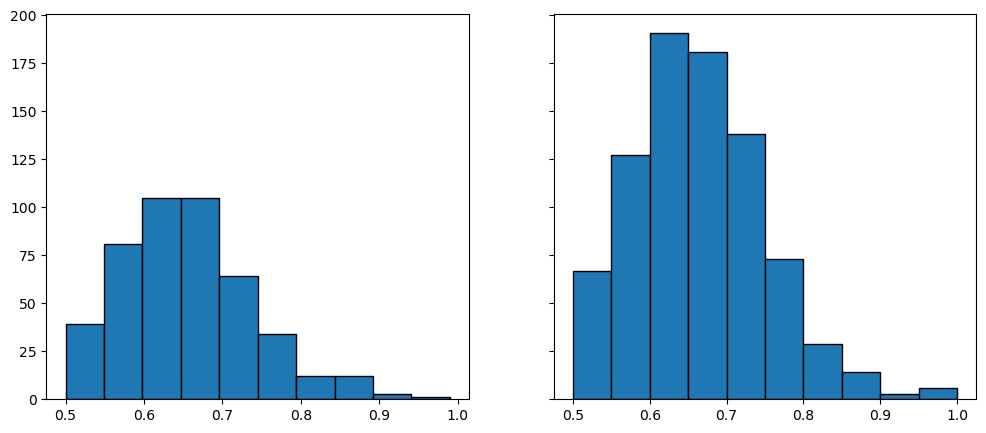

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axs[0].hist(df_fail['半场大于0.5球'], bins=10, edgecolor='black')
axs[1].hist(df_success['半场大于0.5球'], bins=10, edgecolor='black')

plt.show()

/Users/zhangliyao/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhangliyao/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhangliyao/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhangliyao/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20110 (\N{CJK UNIFIED IDEOGRAPH-4E8E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhangliyao/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGR

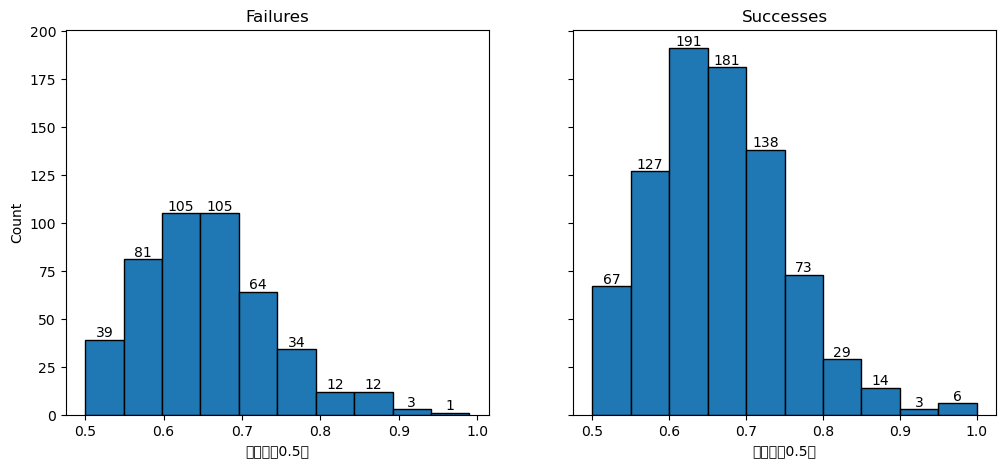

In [6]:
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot histograms and get the counts and bin edges
fail_counts, fail_bins, _ = axs[0].hist(df_fail['半场大于0.5球'].dropna(), bins=10, edgecolor='black')
success_counts, success_bins, _ = axs[1].hist(df_success['半场大于0.5球'].dropna(), bins=10, edgecolor='black')

# Add counts on top of the bars for failures
for count, edge in zip(fail_counts, fail_bins):
    if count > 0:
        axs[0].text(edge + (fail_bins[1] - fail_bins[0]) / 2, count, str(int(count)), ha='center', va='bottom')

# Add counts on top of the bars for successes
for count, edge in zip(success_counts, success_bins):
    if count > 0:
        axs[1].text(edge + (success_bins[1] - success_bins[0]) / 2, count, str(int(count)), ha='center', va='bottom')

# Set titles and labels
axs[0].set_title('Failures')
axs[1].set_title('Successes')
for ax in axs:
    ax.set_xlabel('半场大于0.5球')
axs[0].set_ylabel('Count')

# Show the plot
plt.show()

(array([130., 112., 135.,  98., 112.,  86.,  53.,  75.,  90.]),
 array([ 1.        ,  5.88888889, 10.77777778, 15.66666667, 20.55555556,
        25.44444444, 30.33333333, 35.22222222, 40.11111111, 45.        ]),
 <BarContainer object of 9 artists>)

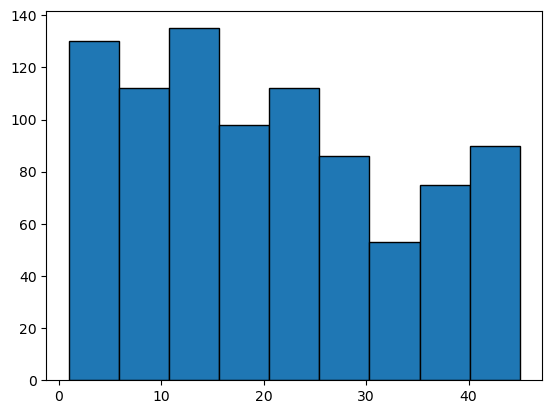

In [8]:
plt.hist(df_success['第一进球'], bins=9, edgecolor='black')

In [7]:
print(df_success['第一进球'].median())
print(df_success['第一进球'].mean())

19.0
20.615039281705947
